# Dataset Preparation: Desktop-Only Top-20 Classes

**Objective**: Filter WebUI Balanced 7K dataset to desktop-only screenshots and retain top 20 UI element classes (10 structural + 10 interactive).

**Input**: 6,996 valid samples × 6 configs (from Notebook 01)

**Output**: 
- Desktop-only: 27,984 screenshots (6,996 samples × 4 desktop configs)
- Top 20 classes: 10 structural (by frequency) + 10 interactive (by importance)
- Train/Val/Test splits with manifests

## 1. Setup and Configuration

In [1]:
import json
import gzip
from pathlib import Path
from collections import Counter, defaultdict
from typing import Dict, List, Tuple
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from PIL import Image, ImageDraw, ImageFont

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

# Dataset paths
DATASET_ROOT = Path(r'C:\WebUIDetection\balanced_7k')
INDEX_FILE = Path(r'C:\WebUIDetection\webui-balanced-7k-20260208T053018Z-1-003\webui-balanced-7k\balanced_7k.json')
OUTPUT_DIR = Path(r'C:\WebUIDetection\Models and outputs\Outputs\02_notebook')

# Create output directories
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / 'splits').mkdir(exist_ok=True)
(OUTPUT_DIR / 'manifests').mkdir(exist_ok=True)

# Desktop configurations only
DESKTOP_CONFIGS = ['default_1280-720', 'default_1366-768', 'default_1536-864', 'default_1920-1080']

print(f'Dataset Root: {DATASET_ROOT}')
print(f'Index File: {INDEX_FILE}')
print(f'Output Directory: {OUTPUT_DIR}')
print(f'Desktop Configurations: {len(DESKTOP_CONFIGS)}')

Dataset Root: C:\WebUIDetection\balanced_7k
Index File: C:\WebUIDetection\webui-balanced-7k-20260208T053018Z-1-003\webui-balanced-7k\balanced_7k.json
Output Directory: C:\WebUIDetection\Models and outputs\Outputs\02_notebook
Desktop Configurations: 4


## 2. Load Valid Samples

In [2]:
# Load all sample IDs
with open(INDEX_FILE, 'r') as f:
    sample_ids = json.load(f)

print(f'Total samples in index: {len(sample_ids)}')

# Quick integrity check for desktop configs
def check_desktop_integrity(sample_id: str) -> bool:
    """Check if sample has all desktop configuration files."""
    sample_dir = DATASET_ROOT / sample_id
    if not sample_dir.exists():
        return False
    
    required_files = ['axtree.json.gz', 'bb.json.gz', 'screenshot.webp']
    
    for config in DESKTOP_CONFIGS:
        for file_suffix in required_files:
            if not (sample_dir / f'{config}-{file_suffix}').exists():
                return False
    return True

# Filter valid samples
print('Checking sample integrity for desktop configurations...')
valid_samples = []
for sample_id in tqdm(sample_ids, desc='Validating samples'):
    if check_desktop_integrity(sample_id):
        valid_samples.append(sample_id)

print(f'\nValid samples with complete desktop configs: {len(valid_samples)}')
print(f'Total desktop screenshots: {len(valid_samples) * len(DESKTOP_CONFIGS):,}')
print(f'Invalid/incomplete samples: {len(sample_ids) - len(valid_samples)}')

Total samples in index: 7000
Checking sample integrity for desktop configurations...


Validating samples: 100%|██████████| 7000/7000 [00:30<00:00, 231.00it/s]


Valid samples with complete desktop configs: 6999
Total desktop screenshots: 27,996
Invalid/incomplete samples: 1


## 3. Extract Class Distribution (Desktop Only)

In [3]:
def load_classes_from_sample(sample_id: str, config: str) -> List[str]:
    """Load class labels (accessibility roles) from axtree.json.gz file."""
    axtree_file = DATASET_ROOT / sample_id / f'{config}-axtree.json.gz'
    try:
        with gzip.open(axtree_file, 'rt') as f:
            axtree = json.load(f)
        
        roles = []
        if 'nodes' in axtree:
            for node in axtree['nodes']:
                role_info = node.get('role', {})
                role_value = role_info.get('value', 'unknown')
                roles.append(role_value)
        
        return roles
    except Exception as e:
        return []

# Extract class distribution across all desktop screenshots
print('Extracting class distribution from desktop configurations...')
desktop_class_counter = Counter()

for sample_id in tqdm(valid_samples, desc='Processing samples'):
    for config in DESKTOP_CONFIGS:
        classes = load_classes_from_sample(sample_id, config)
        desktop_class_counter.update(classes)

# Create DataFrame
class_df = pd.DataFrame([
    {
        'class_name': cls,
        'count': count,
        'percentage': count / sum(desktop_class_counter.values()) * 100
    }
    for cls, count in desktop_class_counter.items()
]).sort_values('count', ascending=False).reset_index(drop=True)

# Save full distribution
class_df.to_csv(OUTPUT_DIR / 'desktop_class_distribution_full.csv', index=False)

print(f'\n{"="*60}')
print('DESKTOP CLASS DISTRIBUTION')
print(f'{"="*60}')
print(f'Total unique classes: {len(class_df)}')
print(f'Total UI elements: {sum(desktop_class_counter.values()):,}')
print(f'\nTop 20 classes:')
print(class_df.head(20).to_string(index=False))

Extracting class distribution from desktop configurations...


Processing samples: 100%|██████████| 6999/6999 [07:32<00:00, 15.48it/s]


DESKTOP CLASS DISTRIBUTION
Total unique classes: 99
Total UI elements: 3,437,127

Top 20 classes:
     class_name   count  percentage
           none 1019706   29.667394
     StaticText  891822   25.946728
           link  382718   11.134823
        generic  232751    6.771673
       listitem  215660    6.274426
      paragraph  148986    4.334609
        heading   96633    2.811447
      LineBreak   68317    1.987619
            img   50018    1.455227
           list   43648    1.269898
     ListMarker   43236    1.257911
    RootWebArea   27996    0.814517
       gridcell   25472    0.741084
        Section   17016    0.495065
       menuitem   16712    0.486220
      separator   10411    0.302898
        article   10372    0.301764
     navigation   10336    0.300716
            row   10216    0.297225
LayoutTableCell    8540    0.248463


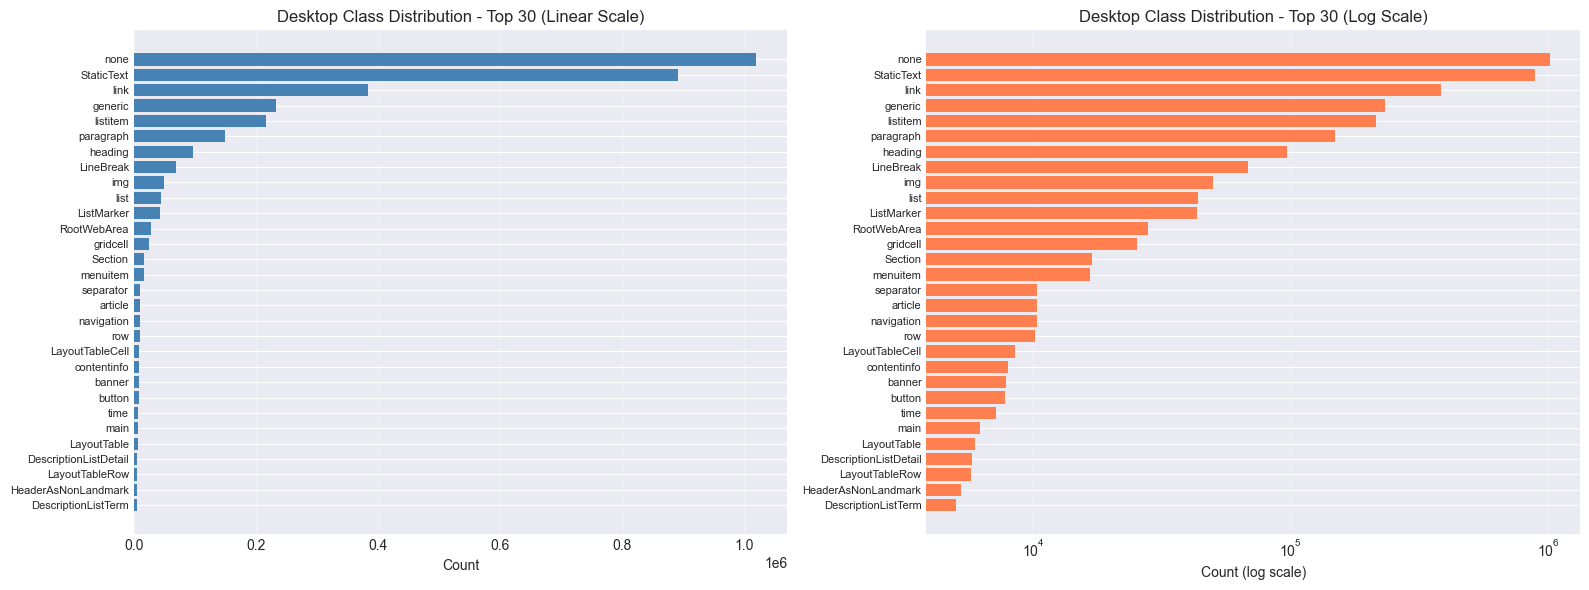

In [4]:
# Visualize full distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Linear scale
ax1 = axes[0]
top_30 = class_df.head(30)
ax1.barh(range(len(top_30)), top_30['count'], color='steelblue')
ax1.set_yticks(range(len(top_30)))
ax1.set_yticklabels(top_30['class_name'], fontsize=8)
ax1.set_xlabel('Count')
ax1.set_title('Desktop Class Distribution - Top 30 (Linear Scale)')
ax1.grid(axis='x', alpha=0.3)
ax1.invert_yaxis()

# Log scale
ax2 = axes[1]
ax2.barh(range(len(top_30)), top_30['count'], color='coral')
ax2.set_yticks(range(len(top_30)))
ax2.set_yticklabels(top_30['class_name'], fontsize=8)
ax2.set_xlabel('Count (log scale)')
ax2.set_title('Desktop Class Distribution - Top 30 (Log Scale)')
ax2.set_xscale('log')
ax2.grid(axis='x', alpha=0.3)
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'desktop_class_distribution_all86.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Identify Top 20 Classes (Structural + Interactive)

In [5]:
# Select top 20 classes: structural (by frequency) + interactive (by importance)
print('Selecting top 20 classes...')
print('Strategy: Top 15 by frequency + 10 critical interactive elements')
print()

# Get top 15 by frequency (structural elements)
top_structural = class_df.head(15)['class_name'].tolist()

# Force-include critical interactive elements (functional importance)
critical_interactive = [
    'button',      # Primary interaction (rank 23)
    'textbox',     # Text input (rank 35)
    'menuitem',    # Already in top 15 (rank 15)
    'combobox',    # Dropdown (rank 44)
    'searchbox',   # Search input (rank 53)
    'search',      # Search region (rank 54)
    'checkbox',    # Boolean input (rank 57)
    'tab',         # Tab navigation (rank 64)
    'dialog',      # Modal dialogs (rank 67)
    'radio'        # Radio buttons (rank 71)
]

# Merge, ensuring no duplicates
top_20_classes = top_structural.copy()
for cls in critical_interactive:
    if cls not in top_20_classes:
        top_20_classes.append(cls)

# Cap at 20 total
top_20_classes = top_20_classes[:20]

print(f'Structural classes (top 15): {len([c for c in top_structural if c in top_20_classes])}')
for i, cls in enumerate(top_structural[:15]):
    if cls in top_20_classes:
        print(f'  {i}: {cls}')

print(f'\nInteractive classes (force-included): {len([c for c in critical_interactive if c in top_20_classes])}')
for cls in critical_interactive:
    if cls in top_20_classes:
        rank = class_df[class_df['class_name'] == cls].index[0] + 1
        print(f'  {cls} (rank {rank})')

print(f'\nTotal selected classes: {len(top_20_classes)}')

# Create class mappings
class_to_id = {cls: idx for idx, cls in enumerate(top_20_classes)}
id_to_class = {idx: cls for cls, idx in class_to_id.items()}

# Save mappings
mapping_data = {
    'class_to_id': class_to_id,
    'id_to_class': id_to_class,
    'top_20_classes': top_20_classes,
    'num_classes': len(top_20_classes),
    'structural_classes': [c for c in top_structural if c in top_20_classes],
    'interactive_classes': [c for c in critical_interactive if c in top_20_classes]
}
with open(OUTPUT_DIR / 'class_mapping_top20.json', 'w') as f:
    json.dump(mapping_data, f, indent=2)

# Display top 20 with statistics
top_20_df = class_df[class_df['class_name'].isin(top_20_classes)].copy()
top_20_df = top_20_df.sort_values('count', ascending=False).reset_index(drop=True)
top_20_df.insert(0, 'class_id', [class_to_id[cls] for cls in top_20_df['class_name']])

print(f'\n{"="*60}')
print('TOP 20 CLASSES (Desktop Only)')
print(f'{"="*60}')
print(top_20_df.to_string(index=False))

total_top20 = top_20_df['count'].sum()
total_all = sum(desktop_class_counter.values())
coverage = (total_top20 / total_all) * 100

print(f'\nTop 20 classes coverage: {total_top20:,} / {total_all:,} = {coverage:.2f}%')
print(f'Elements to be filtered out: {total_all - total_top20:,} ({100-coverage:.2f}%)')


Selecting top 20 classes...
Strategy: Top 15 by frequency + 10 critical interactive elements

Structural classes (top 15): 15
  0: none
  1: StaticText
  2: link
  3: generic
  4: listitem
  5: paragraph
  6: heading
  7: LineBreak
  8: img
  9: list
  10: ListMarker
  11: RootWebArea
  12: gridcell
  13: Section
  14: menuitem

Interactive classes (force-included): 6
  button (rank 23)
  textbox (rank 35)
  menuitem (rank 15)
  combobox (rank 44)
  searchbox (rank 53)
  search (rank 54)

Total selected classes: 20

TOP 20 CLASSES (Desktop Only)
 class_id  class_name   count  percentage
        0        none 1019706   29.667394
        1  StaticText  891822   25.946728
        2        link  382718   11.134823
        3     generic  232751    6.771673
        4    listitem  215660    6.274426
        5   paragraph  148986    4.334609
        6     heading   96633    2.811447
        7   LineBreak   68317    1.987619
        8         img   50018    1.455227
        9        list   4364

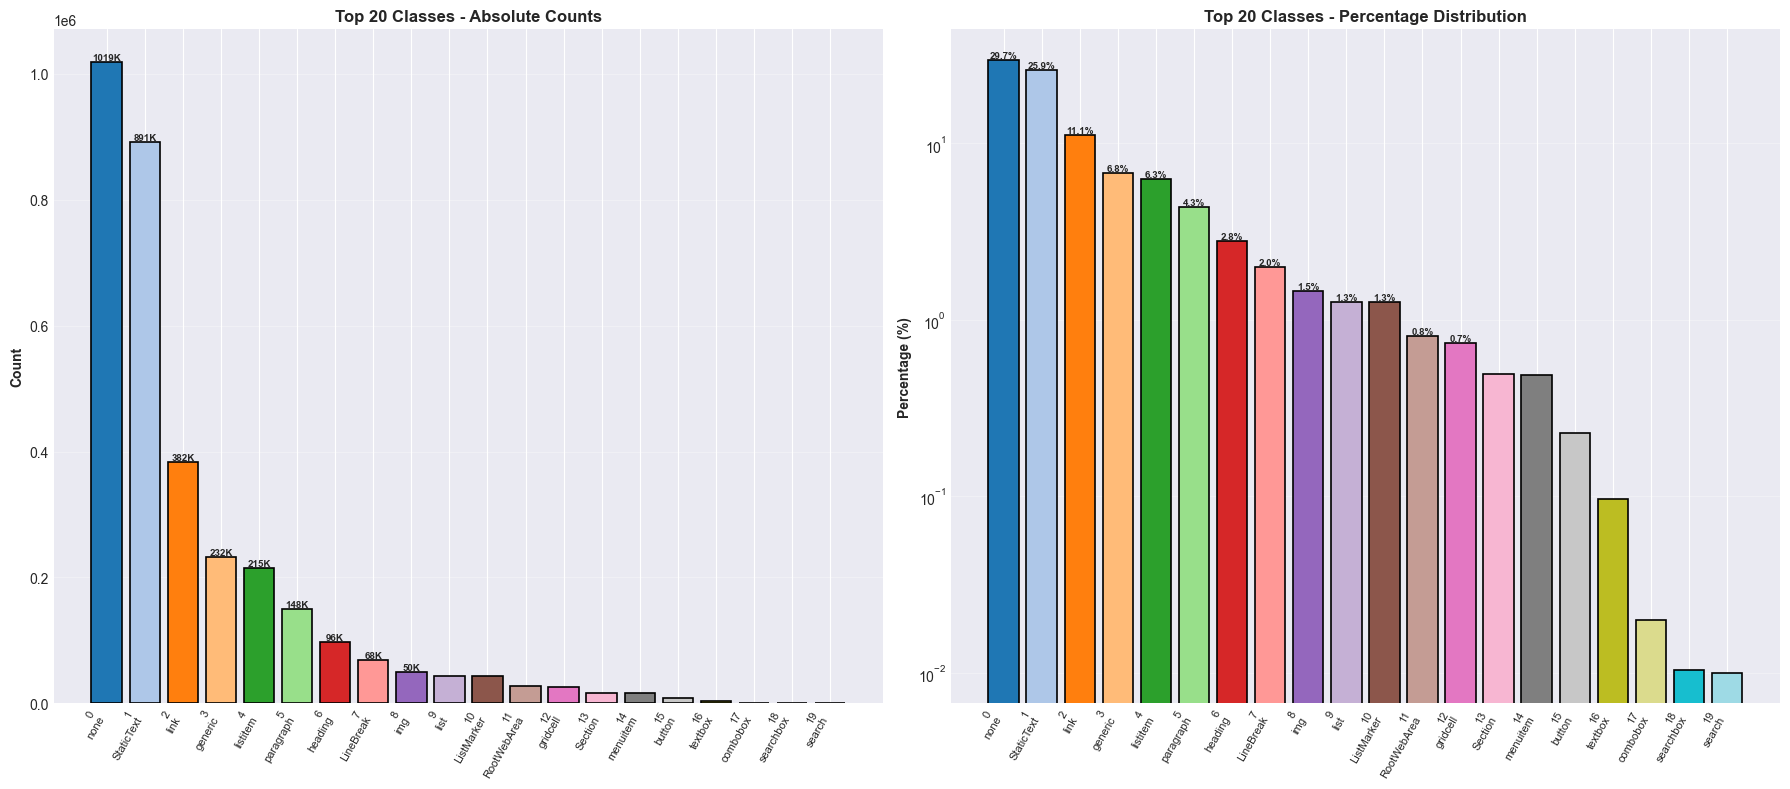

In [7]:
# Visualize top 20
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Bar chart with counts
ax1 = axes[0]
colors = plt.cm.tab20(range(20))
bars = ax1.bar(range(20), top_20_df['count'], color=colors, edgecolor='black', linewidth=1.2)
ax1.set_xticks(range(20))
ax1.set_xticklabels([f"{class_to_id[cls]}\n{cls[:12]}" for cls in top_20_df['class_name']], 
                     rotation=60, ha='right', fontsize=8)
ax1.set_ylabel('Count', fontweight='bold')
ax1.set_title('Top 20 Classes - Absolute Counts', fontweight='bold', fontsize=12)
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars (only for larger bars)
for i, bar in enumerate(bars):
    height = bar.get_height()
    if height > 50000:  # Only label large bars to avoid clutter
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height/1000):.0f}K',
                ha='center', va='bottom', fontsize=7, fontweight='bold')

# Percentage chart
ax2 = axes[1]
bars2 = ax2.bar(range(20), top_20_df['percentage'], color=colors, edgecolor='black', linewidth=1.2)
ax2.set_xticks(range(20))
ax2.set_xticklabels([f"{class_to_id[cls]}\n{cls[:12]}" for cls in top_20_df['class_name']], 
                     rotation=60, ha='right', fontsize=8)
ax2.set_ylabel('Percentage (%)', fontweight='bold')
ax2.set_title('Top 20 Classes - Percentage Distribution', fontweight='bold', fontsize=12)
ax2.grid(axis='y', alpha=0.3)
ax2.set_yscale('log')  # Log scale for better visibility of small percentages

# Add percentage labels for larger bars
for i, bar in enumerate(bars2):
    height = bar.get_height()
    if height > 0.5:  # Only label larger percentages
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'top20_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Build Element-to-Class Mapping (All 20 Classes)

In [8]:
def build_element_class_map(sample_id: str, config: str) -> Dict[str, str]:
    """
    Build mapping from backendDOMNodeId to ARIA role.
    Returns: {element_id: aria_role}
    """
    axtree_file = DATASET_ROOT / sample_id / f'{config}-axtree.json.gz'
    try:
        with gzip.open(axtree_file, 'rt') as f:
            axtree = json.load(f)
        
        element_map = {}
        if 'nodes' in axtree:
            for node in axtree['nodes']:
                node_id = str(node.get('backendDOMNodeId', ''))
                role_info = node.get('role', {})
                role_value = role_info.get('value', 'unknown')
                if node_id:
                    element_map[node_id] = role_value
        
        return element_map
    except Exception as e:
        return {}

# Test on one sample
test_sample = valid_samples[0]
test_config = DESKTOP_CONFIGS[0]
test_map = build_element_class_map(test_sample, test_config)
print(f'Sample: {test_sample}, Config: {test_config}')
print(f'Element-to-class mappings created: {len(test_map)}')
print(f'\nFirst 10 mappings:')
for i, (elem_id, role) in enumerate(list(test_map.items())[:10]):
    print(f'  {elem_id}: {role}')

Sample: 1656507072588, Config: default_1280-720
Element-to-class mappings created: 45

First 10 mappings:
  3: RootWebArea
  11: none
  12: none
  13: heading
  14: LineBreak
  15: none
  16: LineBreak
  6: LayoutTable
  17: LineBreak
  18: LineBreak


## 6. Filter Bounding Boxes by Top 20 Classes

In [9]:
def load_bounding_boxes(sample_id: str, config: str) -> Dict:
    """Load bounding boxes from bb.json.gz file."""
    bb_file = DATASET_ROOT / sample_id / f'{config}-bb.json.gz'
    try:
        with gzip.open(bb_file, 'rt') as f:
            bboxes = json.load(f)
        return bboxes
    except Exception:
        return {}

def filter_bboxes_top20(bboxes: Dict, element_class_map: Dict[str, str], 
                        top_20_set: set) -> Dict:
    """
    Filter bounding boxes to keep only those belonging to top 20 classes.
    Returns: {element_id: bbox_dict} for top 20 classes only
    """
    filtered = {}
    for elem_id, bbox in bboxes.items():
        if bbox is None or not isinstance(bbox, dict):
            continue
        
        elem_class = element_class_map.get(elem_id, 'unknown')
        if elem_class in top_20_set:
            filtered[elem_id] = bbox
    
    return filtered

# Process all samples and collect statistics
print('Filtering bounding boxes to top 20 classes...')
top_20_set = set(top_20_classes)

filtering_stats = []
filtered_data = {}  # Store filtered bboxes for later use

for sample_id in tqdm(valid_samples, desc='Filtering samples'):
    filtered_data[sample_id] = {}
    
    for config in DESKTOP_CONFIGS:
        # Load data
        bboxes = load_bounding_boxes(sample_id, config)
        element_class_map = build_element_class_map(sample_id, config)
        
        # Filter
        filtered_bboxes = filter_bboxes_top20(bboxes, element_class_map, top_20_set)
        
        # Store filtered data
        filtered_data[sample_id][config] = {
            'bboxes': filtered_bboxes,
            'element_class_map': element_class_map
        }
        
        # Collect stats
        original_count = len(bboxes)
        filtered_count = len(filtered_bboxes)
        retention_rate = (filtered_count / original_count * 100) if original_count > 0 else 0
        
        filtering_stats.append({
            'sample_id': sample_id,
            'config': config,
            'original_count': original_count,
            'filtered_count': filtered_count,
            'retention_rate': retention_rate
        })

# Create statistics DataFrame
stats_df = pd.DataFrame(filtering_stats)

# Save statistics
summary_stats = {
    'total_screenshots': len(stats_df),
    'total_boxes_original': int(stats_df['original_count'].sum()),
    'total_boxes_filtered': int(stats_df['filtered_count'].sum()),
    'overall_retention_rate': float(stats_df['filtered_count'].sum() / stats_df['original_count'].sum() * 100),
    'mean_boxes_per_screenshot_original': float(stats_df['original_count'].mean()),
    'mean_boxes_per_screenshot_filtered': float(stats_df['filtered_count'].mean()),
    'by_config': {}
}

for config in DESKTOP_CONFIGS:
    config_stats = stats_df[stats_df['config'] == config]
    summary_stats['by_config'][config] = {
        'original': int(config_stats['original_count'].sum()),
        'filtered': int(config_stats['filtered_count'].sum()),
        'retention_rate': float(config_stats['filtered_count'].sum() / config_stats['original_count'].sum() * 100)
    }

with open(OUTPUT_DIR / 'filtering_statistics.json', 'w') as f:
    json.dump(summary_stats, f, indent=2)

print(f'\n{"="*60}')
print('FILTERING STATISTICS')
print(f'{"="*60}')
print(f'Total screenshots processed: {summary_stats["total_screenshots"]:,}')
print(f'Original bounding boxes: {summary_stats["total_boxes_original"]:,}')
print(f'Filtered bounding boxes (top 20): {summary_stats["total_boxes_filtered"]:,}')
print(f'Overall retention rate: {summary_stats["overall_retention_rate"]:.2f}%')
print(f'\nMean boxes per screenshot:')
print(f'  Original: {summary_stats["mean_boxes_per_screenshot_original"]:.1f}')
print(f'  Filtered: {summary_stats["mean_boxes_per_screenshot_filtered"]:.1f}')

Filtering bounding boxes to top 20 classes...


Filtering samples: 100%|██████████| 6999/6999 [06:29<00:00, 17.98it/s]


FILTERING STATISTICS
Total screenshots processed: 27,996
Original bounding boxes: 3,348,797
Filtered bounding boxes (top 20): 2,683,018
Overall retention rate: 80.12%

Mean boxes per screenshot:
  Original: 119.6
  Filtered: 95.8


## 7. Analyze Element Density Distribution

In [10]:
# Calculate average element density per sample (across 4 desktop configs)
sample_density_data = []

for sample_id in valid_samples:
    counts = []
    for config in DESKTOP_CONFIGS:
        filtered_count = len(filtered_data[sample_id][config]['bboxes'])
        counts.append(filtered_count)
    
    avg_elements = np.mean(counts)
    
    # Categorize density
    if avg_elements < 50:
        density_category = 'low'
    elif avg_elements <= 150:
        density_category = 'medium'
    else:
        density_category = 'high'
    
    sample_density_data.append({
        'sample_id': sample_id,
        'avg_elements': avg_elements,
        'min_elements': min(counts),
        'max_elements': max(counts),
        'density_category': density_category
    })

# Create DataFrame
density_df = pd.DataFrame(sample_density_data)
density_df.to_csv(OUTPUT_DIR / 'sample_density_info.csv', index=False)

# Print statistics
print(f'\n{"="*60}')
print('ELEMENT DENSITY DISTRIBUTION')
print(f'{"="*60}')
print(f'\nDensity categories:')
print(density_df['density_category'].value_counts().to_string())
print(f'\nStatistics by category:')
print(density_df.groupby('density_category')['avg_elements'].describe())


ELEMENT DENSITY DISTRIBUTION

Density categories:
density_category
low       3487
medium    1791
high      1721

Statistics by category:
                   count        mean         std    min    25%    50%    75%  \
density_category                                                               
high              1721.0  253.269175  104.080472  151.0  186.0  232.0  289.0   
low               3487.0   20.129983   13.947627    4.0    8.0   13.0   35.0   
medium            1791.0   91.951424   29.674289   50.0   66.0   87.0  117.0   

                     max  
density_category          
high              1239.0  
low                 49.0  
medium             150.0  


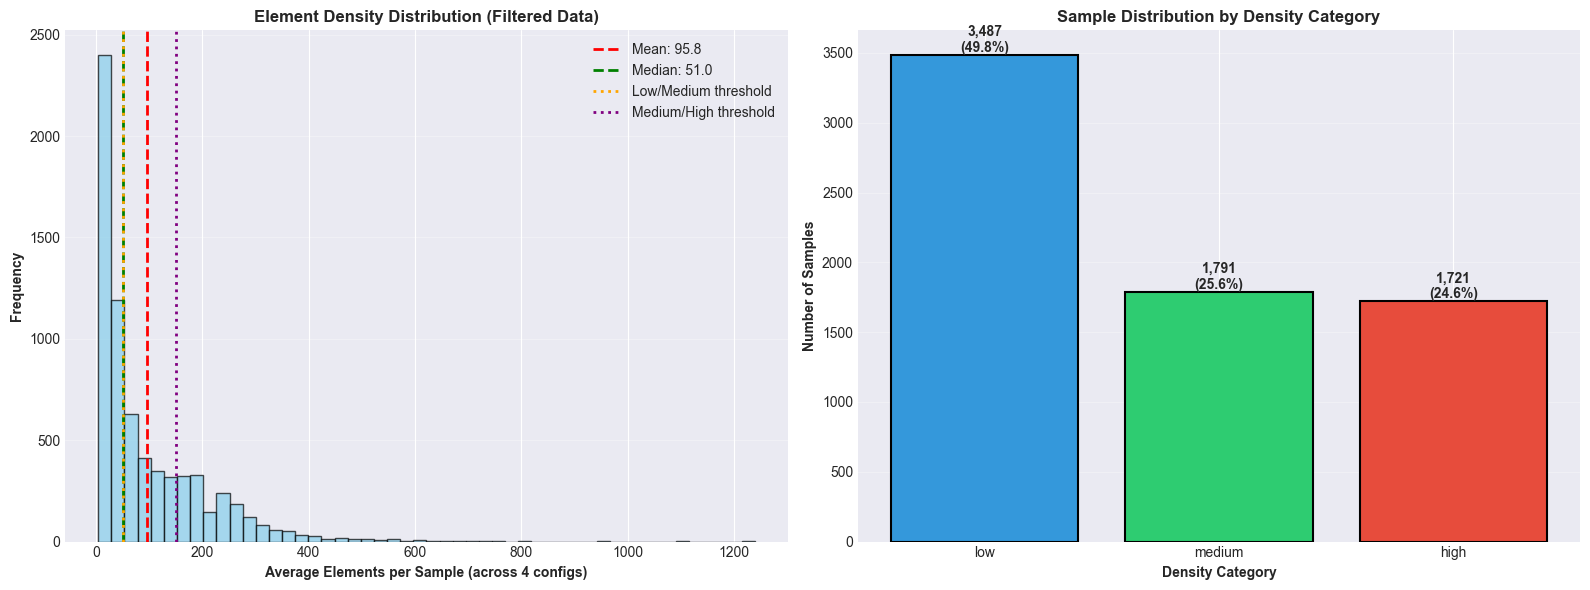

In [11]:
# Visualize element density
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
ax1 = axes[0]
ax1.hist(density_df['avg_elements'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax1.axvline(density_df['avg_elements'].mean(), color='red', linestyle='--', 
           linewidth=2, label=f'Mean: {density_df["avg_elements"].mean():.1f}')
ax1.axvline(density_df['avg_elements'].median(), color='green', linestyle='--',
           linewidth=2, label=f'Median: {density_df["avg_elements"].median():.1f}')
ax1.axvline(50, color='orange', linestyle=':', linewidth=2, label='Low/Medium threshold')
ax1.axvline(150, color='purple', linestyle=':', linewidth=2, label='Medium/High threshold')
ax1.set_xlabel('Average Elements per Sample (across 4 configs)', fontweight='bold')
ax1.set_ylabel('Frequency', fontweight='bold')
ax1.set_title('Element Density Distribution (Filtered Data)', fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Category counts
ax2 = axes[1]
category_counts = density_df['density_category'].value_counts()
colors_cat = {'low': '#3498db', 'medium': '#2ecc71', 'high': '#e74c3c'}
bars = ax2.bar(category_counts.index, category_counts.values, 
               color=[colors_cat[cat] for cat in category_counts.index],
               edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Density Category', fontweight='bold')
ax2.set_ylabel('Number of Samples', fontweight='bold')
ax2.set_title('Sample Distribution by Density Category', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}\n({height/len(density_df)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'element_density_filtered.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Create Stratified Train/Val/Test Split

In [12]:
# Prepare data for splitting
X = density_df['sample_id'].values
y = density_df['density_category'].values

# First split: train (70%) and temp (30%)
train_samples, temp_samples, train_labels, temp_labels = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# Second split: val (50% of temp = 15%) and test (50% of temp = 15%)
val_samples, test_samples, val_labels, test_labels = train_test_split(
    temp_samples, temp_labels, test_size=0.50, stratify=temp_labels, random_state=42
)

# Convert to lists
train_samples = train_samples.tolist()
val_samples = val_samples.tolist()
test_samples = test_samples.tolist()

# Save splits
with open(OUTPUT_DIR / 'splits' / 'train_samples.json', 'w') as f:
    json.dump(train_samples, f, indent=2)
with open(OUTPUT_DIR / 'splits' / 'val_samples.json', 'w') as f:
    json.dump(val_samples, f, indent=2)
with open(OUTPUT_DIR / 'splits' / 'test_samples.json', 'w') as f:
    json.dump(test_samples, f, indent=2)

print(f'{"="*60}')
print('TRAIN/VAL/TEST SPLIT (Sample Level)')
print(f'{"="*60}')
print(f'Train samples: {len(train_samples)} ({len(train_samples)/len(valid_samples)*100:.1f}%)')
print(f'Val samples: {len(val_samples)} ({len(val_samples)/len(valid_samples)*100:.1f}%)')
print(f'Test samples: {len(test_samples)} ({len(test_samples)/len(valid_samples)*100:.1f}%)')
print(f'\nTotal screenshots:')
print(f'Train: {len(train_samples) * 4:,} screenshots')
print(f'Val: {len(val_samples) * 4:,} screenshots')
print(f'Test: {len(test_samples) * 4:,} screenshots')

# Verify no overlap
assert len(set(train_samples) & set(val_samples)) == 0, 'Train-Val overlap detected!'
assert len(set(train_samples) & set(test_samples)) == 0, 'Train-Test overlap detected!'
assert len(set(val_samples) & set(test_samples)) == 0, 'Val-Test overlap detected!'
print('\n✓ No overlap between splits verified')

TRAIN/VAL/TEST SPLIT (Sample Level)
Train samples: 4899 (70.0%)
Val samples: 1050 (15.0%)
Test samples: 1050 (15.0%)

Total screenshots:
Train: 19,596 screenshots
Val: 4,200 screenshots
Test: 4,200 screenshots

✓ No overlap between splits verified


## 9. Generate Dataset Manifests

In [13]:
def create_manifest(sample_list: List[str], split_name: str) -> List[Dict]:
    """Create manifest with screenshot-level entries."""
    manifest = []
    
    for sample_id in tqdm(sample_list, desc=f'Creating {split_name} manifest'):
        sample_density_info = density_df[density_df['sample_id'] == sample_id].iloc[0]
        
        for config in DESKTOP_CONFIGS:
            # Get filtered bboxes for this screenshot
            bboxes = filtered_data[sample_id][config]['bboxes']
            element_map = filtered_data[sample_id][config]['element_class_map']
            
            # Get classes present in this screenshot
            classes_present = set()
            for elem_id in bboxes.keys():
                elem_class = element_map.get(elem_id, 'unknown')
                if elem_class in class_to_id:
                    classes_present.add(class_to_id[elem_class])
            
            manifest.append({
                'sample_id': sample_id,
                'config': config,
                'num_elements': len(bboxes),
                'density_category': sample_density_info['density_category'],
                'classes_present': sorted(list(classes_present)),
                'image_path': f'balanced_7k/{sample_id}/{config}-screenshot.webp',
                'annotation_data': {
                    'bboxes': bboxes,
                    'element_class_map': element_map
                }
            })
    
    return manifest

# Create manifests
print('Generating manifests...')
train_manifest = create_manifest(train_samples, 'train')
val_manifest = create_manifest(val_samples, 'val')
test_manifest = create_manifest(test_samples, 'test')

# Save manifests
with open(OUTPUT_DIR / 'manifests' / 'train_manifest.json', 'w') as f:
    json.dump(train_manifest, f, indent=2)
with open(OUTPUT_DIR / 'manifests' / 'val_manifest.json', 'w') as f:
    json.dump(val_manifest, f, indent=2)
with open(OUTPUT_DIR / 'manifests' / 'test_manifest.json', 'w') as f:
    json.dump(test_manifest, f, indent=2)

print(f'\n{"="*60}')
print('MANIFESTS CREATED')
print(f'{"="*60}')
print(f'Train manifest: {len(train_manifest)} screenshots')
print(f'Val manifest: {len(val_manifest)} screenshots')
print(f'Test manifest: {len(test_manifest)} screenshots')
print(f'\nManifests saved to: {OUTPUT_DIR / "manifests"}')

Generating manifests...


Creating test manifest: 100%|██████████| 1050/1050 [00:00<00:00, 1085.60it/s]



MANIFESTS CREATED
Train manifest: 19596 screenshots
Val manifest: 4200 screenshots
Test manifest: 4200 screenshots

Manifests saved to: C:\WebUIDetection\Models and outputs\Outputs\02_notebook\manifests


## 10. Validate and Analyze Splits

In [14]:
def analyze_split(manifest: List[Dict], split_name: str) -> Dict:
    """Analyze statistics for a split."""
    total_elements = sum(item['num_elements'] for item in manifest)
    
    # Density distribution
    density_dist = Counter(item['density_category'] for item in manifest)
    
    # Class distribution
    class_dist = Counter()
    for item in manifest:
        for class_id in item['classes_present']:
            class_dist[class_id] += 1
    
    return {
        'split_name': split_name,
        'num_screenshots': len(manifest),
        'num_samples': len(set(item['sample_id'] for item in manifest)),
        'total_elements': total_elements,
        'avg_elements_per_screenshot': total_elements / len(manifest),
        'density_distribution': dict(density_dist),
        'class_distribution': dict(class_dist)
    }

# Analyze all splits
train_stats = analyze_split(train_manifest, 'train')
val_stats = analyze_split(val_manifest, 'val')
test_stats = analyze_split(test_manifest, 'test')

# Print statistics
for stats in [train_stats, val_stats, test_stats]:
    print(f'\n{"="*60}')
    print(f'{stats["split_name"].upper()} SPLIT STATISTICS')
    print(f'{"="*60}')
    print(f'Samples: {stats["num_samples"]:,}')
    print(f'Screenshots: {stats["num_screenshots"]:,}')
    print(f'Total elements: {stats["total_elements"]:,}')
    print(f'Avg elements per screenshot: {stats["avg_elements_per_screenshot"]:.1f}')
    print(f'\nDensity distribution:')
    for category in ['low', 'medium', 'high']:
        count = stats['density_distribution'].get(category, 0)
        pct = count / stats['num_screenshots'] * 100
        print(f'  {category}: {count} ({pct:.1f}%)')
    print(f'\nTop 5 most frequent classes:')
    sorted_classes = sorted(stats['class_distribution'].items(), key=lambda x: x[1], reverse=True)[:5]
    for class_id, count in sorted_classes:
        print(f'  Class {class_id} ({id_to_class[class_id]}): {count}')


TRAIN SPLIT STATISTICS
Samples: 4,899
Screenshots: 19,596
Total elements: 1,894,929
Avg elements per screenshot: 96.7

Density distribution:
  low: 9764 (49.8%)
  medium: 5012 (25.6%)
  high: 4820 (24.6%)

Top 5 most frequent classes:
  Class 0 (none): 19596
  Class 11 (RootWebArea): 19596
  Class 1 (StaticText): 19556
  Class 6 (heading): 17468
  Class 3 (generic): 15765

VAL SPLIT STATISTICS
Samples: 1,050
Screenshots: 4,200
Total elements: 392,017
Avg elements per screenshot: 93.3

Density distribution:
  low: 2092 (49.8%)
  medium: 1076 (25.6%)
  high: 1032 (24.6%)

Top 5 most frequent classes:
  Class 0 (none): 4200
  Class 11 (RootWebArea): 4200
  Class 1 (StaticText): 4184
  Class 6 (heading): 3744
  Class 3 (generic): 3396

TEST SPLIT STATISTICS
Samples: 1,050
Screenshots: 4,200
Total elements: 396,072
Avg elements per screenshot: 94.3

Density distribution:
  low: 2092 (49.8%)
  medium: 1076 (25.6%)
  high: 1032 (24.6%)

Top 5 most frequent classes:
  Class 0 (none): 4200
  C

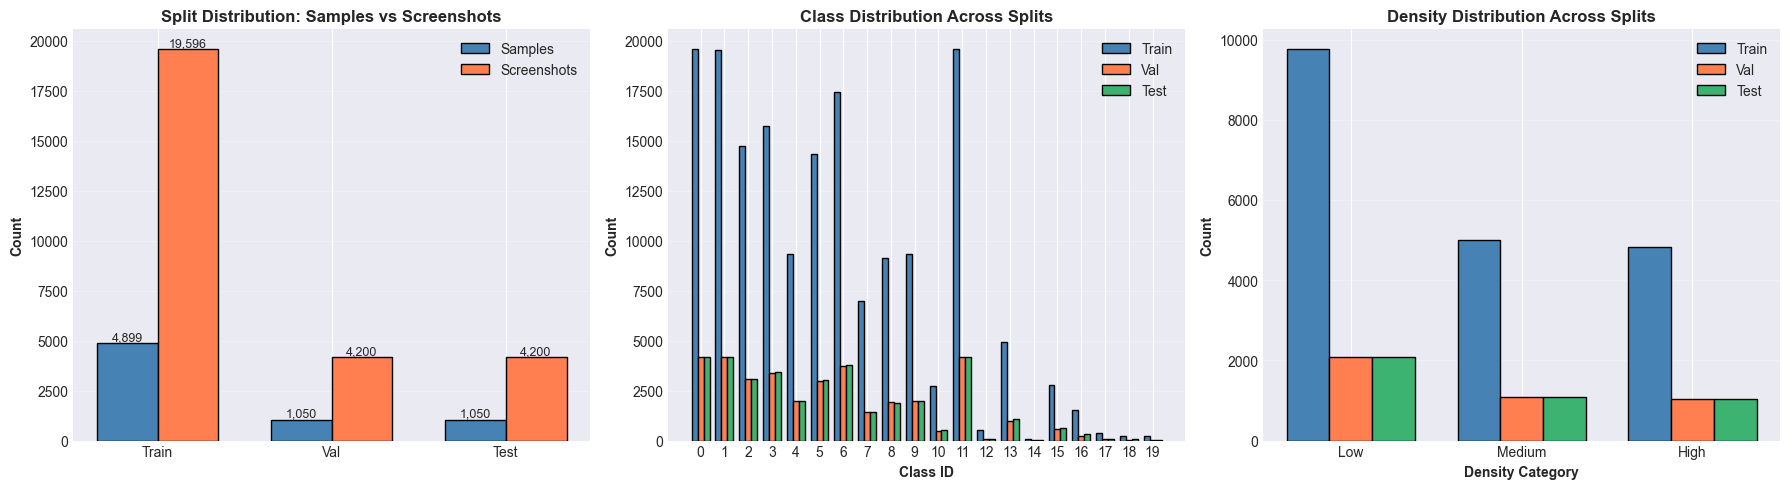

In [15]:
# Visualize split distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Split sizes
ax1 = axes[0]
splits = ['Train', 'Val', 'Test']
samples = [train_stats['num_samples'], val_stats['num_samples'], test_stats['num_samples']]
screenshots = [train_stats['num_screenshots'], val_stats['num_screenshots'], test_stats['num_screenshots']]

x = np.arange(len(splits))
width = 0.35
bars1 = ax1.bar(x - width/2, samples, width, label='Samples', color='steelblue', edgecolor='black')
bars2 = ax1.bar(x + width/2, screenshots, width, label='Screenshots', color='coral', edgecolor='black')

ax1.set_ylabel('Count', fontweight='bold')
ax1.set_title('Split Distribution: Samples vs Screenshots', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(splits)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}', ha='center', va='bottom', fontsize=9)

# 2. Class distribution across splits
ax2 = axes[1]
class_ids = list(range(20))
train_class_counts = [train_stats['class_distribution'].get(i, 0) for i in class_ids]
val_class_counts = [val_stats['class_distribution'].get(i, 0) for i in class_ids]
test_class_counts = [test_stats['class_distribution'].get(i, 0) for i in class_ids]

x = np.arange(len(class_ids))
width = 0.25
ax2.bar(x - width, train_class_counts, width, label='Train', color='steelblue', edgecolor='black')
ax2.bar(x, val_class_counts, width, label='Val', color='coral', edgecolor='black')
ax2.bar(x + width, test_class_counts, width, label='Test', color='mediumseagreen', edgecolor='black')

ax2.set_ylabel('Count', fontweight='bold')
ax2.set_xlabel('Class ID', fontweight='bold')
ax2.set_title('Class Distribution Across Splits', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(class_ids)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 3. Density distribution across splits
ax3 = axes[2]
categories = ['low', 'medium', 'high']
train_density = [train_stats['density_distribution'].get(cat, 0) for cat in categories]
val_density = [val_stats['density_distribution'].get(cat, 0) for cat in categories]
test_density = [test_stats['density_distribution'].get(cat, 0) for cat in categories]

x = np.arange(len(categories))
width = 0.25
ax3.bar(x - width, train_density, width, label='Train', color='steelblue', edgecolor='black')
ax3.bar(x, val_density, width, label='Val', color='coral', edgecolor='black')
ax3.bar(x + width, test_density, width, label='Test', color='mediumseagreen', edgecolor='black')

ax3.set_ylabel('Count', fontweight='bold')
ax3.set_xlabel('Density Category', fontweight='bold')
ax3.set_title('Density Distribution Across Splits', fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels([cat.capitalize() for cat in categories])
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'split_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. Create Dataset Summary

In [16]:
# Compile comprehensive summary
dataset_summary = {
    'dataset_name': 'WebUI Balanced 7K - Desktop Top 20',
    'creation_date': '2026-02-08',
    'total_valid_samples': len(valid_samples),
    'total_desktop_screenshots': len(valid_samples) * 4,
    'desktop_configs': DESKTOP_CONFIGS,
    'num_classes': 20,
    'top_20_classes': {
        'class_names': top_20_classes,
        'class_mapping': class_to_id,
        'id_to_class': id_to_class,
        'structural_classes': [c for c in top_structural if c in top_20_classes],
        'interactive_classes': [c for c in critical_interactive if c in top_20_classes]
    },
    'filtering_statistics': summary_stats,
    'splits': {
        'train': {
            'num_samples': train_stats['num_samples'],
            'num_screenshots': train_stats['num_screenshots'],
            'total_elements': train_stats['total_elements'],
            'avg_elements_per_screenshot': train_stats['avg_elements_per_screenshot'],
            'percentage': len(train_samples) / len(valid_samples) * 100
        },
        'val': {
            'num_samples': val_stats['num_samples'],
            'num_screenshots': val_stats['num_screenshots'],
            'total_elements': val_stats['total_elements'],
            'avg_elements_per_screenshot': val_stats['avg_elements_per_screenshot'],
            'percentage': len(val_samples) / len(valid_samples) * 100
        },
        'test': {
            'num_samples': test_stats['num_samples'],
            'num_screenshots': test_stats['num_screenshots'],
            'total_elements': test_stats['total_elements'],
            'avg_elements_per_screenshot': test_stats['avg_elements_per_screenshot'],
            'percentage': len(test_samples) / len(valid_samples) * 100
        }
    },
    'output_files': {
        'class_mapping': 'class_mapping_top20.json',
        'filtering_stats': 'filtering_statistics.json',
        'density_info': 'sample_density_info.csv',
        'splits': {
            'train': 'splits/train_samples.json',
            'val': 'splits/val_samples.json',
            'test': 'splits/test_samples.json'
        },
        'manifests': {
            'train': 'manifests/train_manifest.json',
            'val': 'manifests/val_manifest.json',
            'test': 'manifests/test_manifest.json'
        }
    }
}

# Save summary
with open(OUTPUT_DIR / 'dataset_summary.json', 'w') as f:
    json.dump(dataset_summary, f, indent=2)

print(f'{"="*60}')
print('DATASET SUMMARY')
print(f'{"="*60}')
print(f'Dataset: {dataset_summary["dataset_name"]}')
print(f'Total samples: {dataset_summary["total_valid_samples"]:,}')
print(f'\nTop 20 classes (10 structural + 10 interactive):')
for i, cls in enumerate(top_20_classes):
    class_type = 'S' if cls in mapping_data['structural_classes'] else 'I'
    print(f'  {i}: {cls} [{class_type}]')
print(f'\nRetention rate: {summary_stats["overall_retention_rate"]:.2f}%')
print(f'\nSplit distribution:')
print(f'  Train: {len(train_samples):,} samples ({len(train_samples)/len(valid_samples)*100:.1f}%)')
print(f'  Val: {len(val_samples):,} samples ({len(val_samples)/len(valid_samples)*100:.1f}%)')
print(f'  Test: {len(test_samples):,} samples ({len(test_samples)/len(valid_samples)*100:.1f}%)')

print(f'\nAll outputs saved to: {OUTPUT_DIR}')

DATASET SUMMARY
Dataset: WebUI Balanced 7K - Desktop Top 20
Total samples: 6,999

Top 20 classes (10 structural + 10 interactive):
  0: none [S]
  1: StaticText [S]
  2: link [S]
  3: generic [S]
  4: listitem [S]
  5: paragraph [S]
  6: heading [S]
  7: LineBreak [S]
  8: img [S]
  9: list [S]
  10: ListMarker [S]
  11: RootWebArea [S]
  12: gridcell [S]
  13: Section [S]
  14: menuitem [S]
  15: button [I]
  16: textbox [I]
  17: combobox [I]
  18: searchbox [I]
  19: search [I]

Retention rate: 80.12%

Split distribution:
  Train: 4,899 samples (70.0%)
  Val: 1,050 samples (15.0%)
  Test: 1,050 samples (15.0%)

All outputs saved to: C:\WebUIDetection\Models and outputs\Outputs\02_notebook


## 12. Visualize Sample Annotations

Visualizing 6 random training samples with config: default_1920-1080


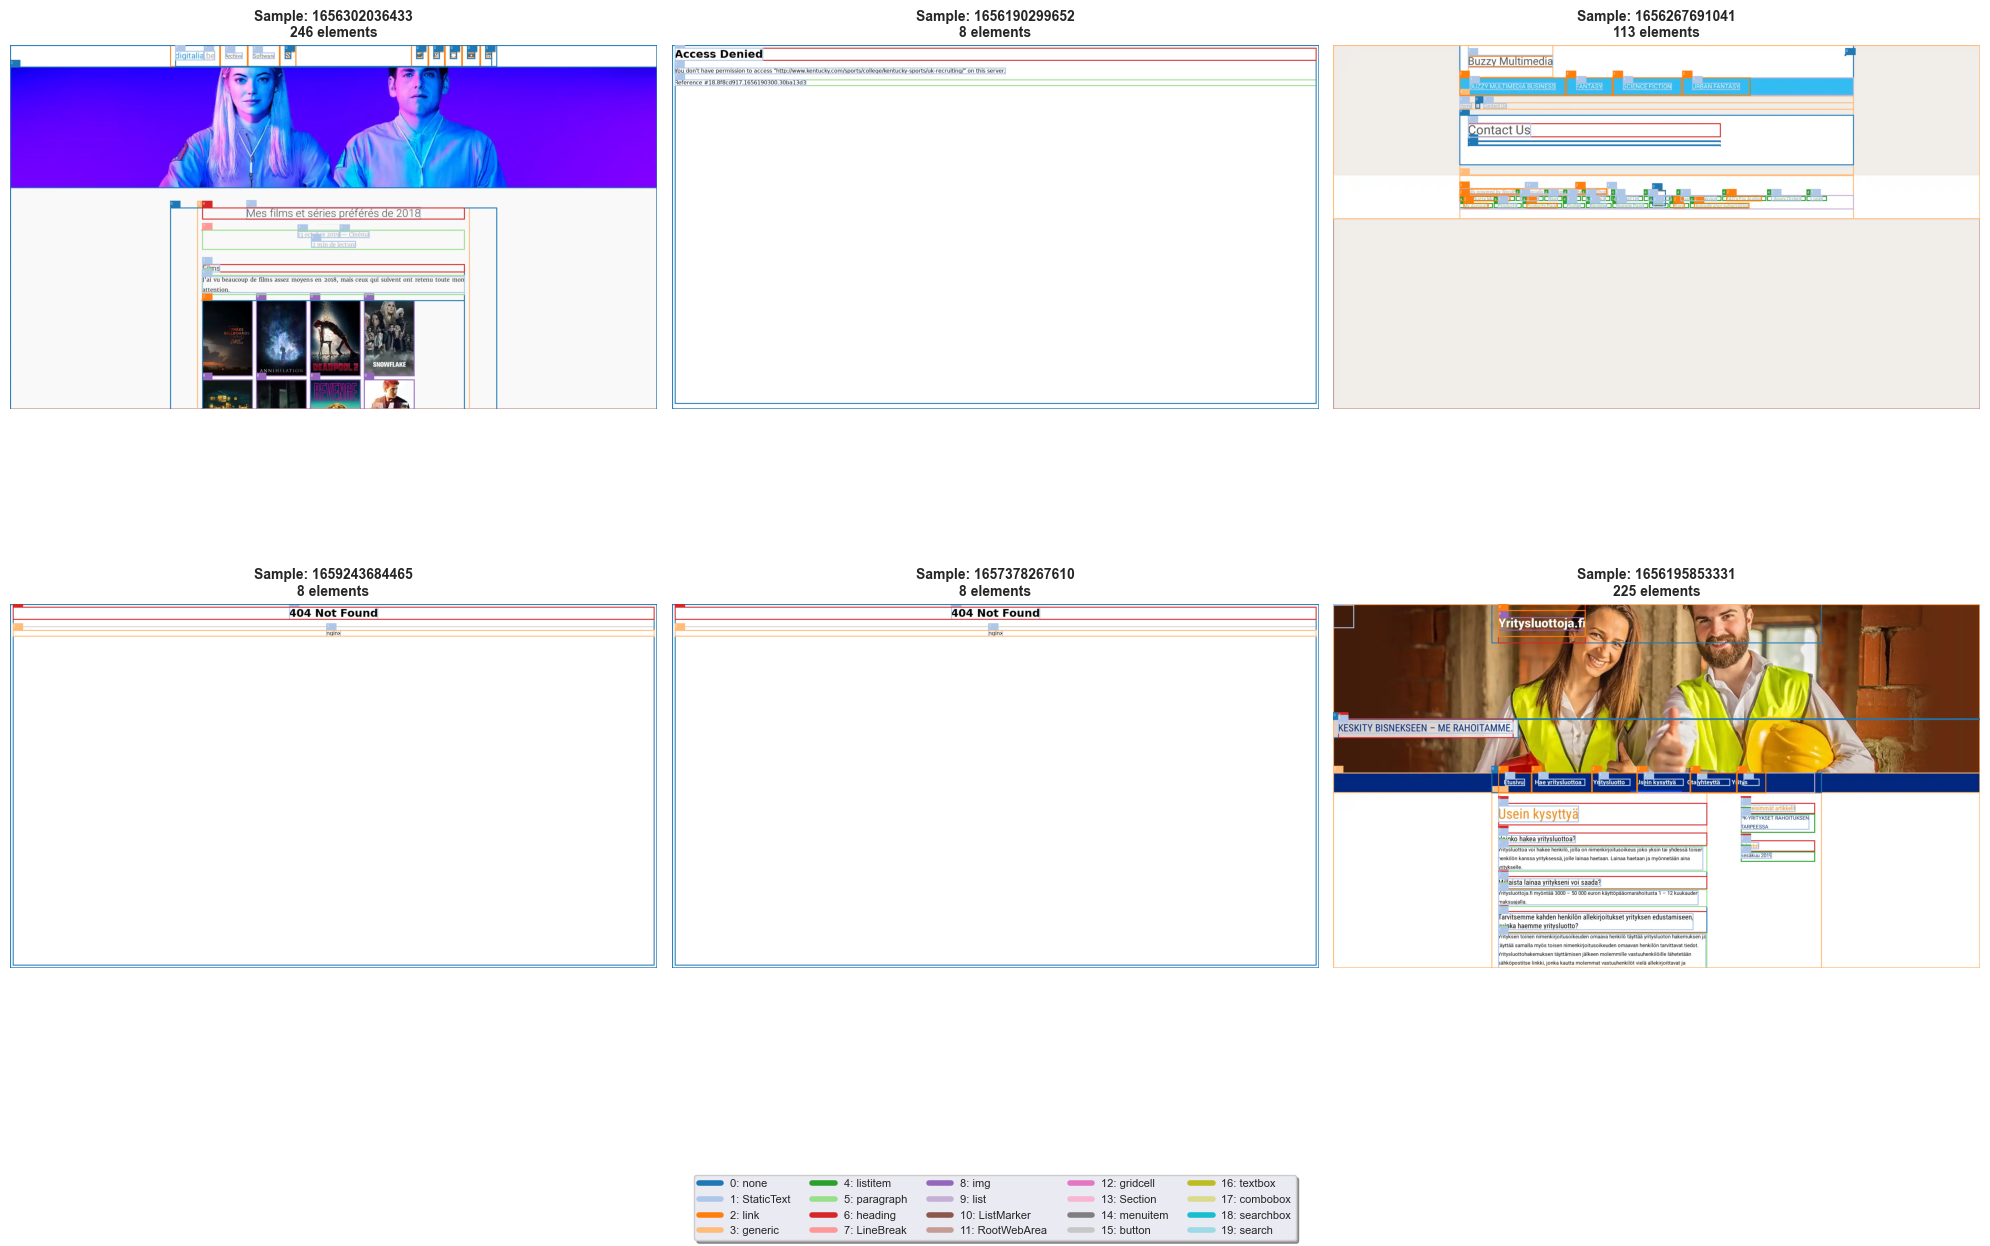


Visualization saved to: C:\WebUIDetection\Models and outputs\Outputs\02_notebook\sample_annotations_filtered.png


In [17]:
# Select random samples for visualization
np.random.seed(42)
sample_indices = np.random.choice(len(train_samples), size=min(6, len(train_samples)), replace=False)
vis_samples = [train_samples[i] for i in sample_indices]
vis_config = DESKTOP_CONFIGS[3]  # Use 1920x1080

# Create color map for classes (20 classes)
colors_map = plt.cm.tab20(range(20))
colors_rgb = [(int(c[0]*255), int(c[1]*255), int(c[2]*255)) for c in colors_map]

print(f'Visualizing {len(vis_samples)} random training samples with config: {vis_config}')

fig, axes = plt.subplots(2, 3, figsize=(20, 14))
axes = axes.flatten()

for idx, sample_id in enumerate(vis_samples):
    # Load screenshot
    img_path = DATASET_ROOT / sample_id / f'{vis_config}-screenshot.webp'
    img = Image.open(img_path).convert('RGB')
    draw = ImageDraw.Draw(img)
    
    # Get filtered bboxes and element map
    bboxes = filtered_data[sample_id][vis_config]['bboxes']
    element_map = filtered_data[sample_id][vis_config]['element_class_map']
    
    # Draw bounding boxes
    for elem_id, bbox in bboxes.items():
        elem_class = element_map.get(elem_id, 'unknown')
        if elem_class not in class_to_id:
            continue
        
        class_id = class_to_id[elem_class]
        color = colors_rgb[class_id]
        
        x, y, w, h = bbox['x'], bbox['y'], bbox['width'], bbox['height']
        draw.rectangle([x, y, x+w, y+h], outline=color, width=3)
        
        # Add class label
        label = f"{class_id}"
        draw.rectangle([x, y-20, x+30, y], fill=color)
        draw.text((x+2, y-18), label, fill='white')
    
    # Display
    ax = axes[idx]
    ax.imshow(img)
    ax.set_title(f'Sample: {sample_id}\n{len(bboxes)} elements', fontsize=10, fontweight='bold')
    ax.axis('off')

# Create legend
legend_elements = [plt.Line2D([0], [0], color=colors_map[i], lw=4, 
                              label=f'{i}: {id_to_class[i][:20]}') 
                  for i in range(20)]
fig.legend(handles=legend_elements, loc='lower center', ncol=5, fontsize=8, 
          frameon=True, fancybox=True, shadow=True)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(OUTPUT_DIR / 'sample_annotations_filtered.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nVisualization saved to: {OUTPUT_DIR / "sample_annotations_filtered.png"}')

## 13. Export Class Reference

In [18]:
# Create human-readable class reference
class_descriptions = {
    'generic': 'Generic container element (div, span)',
    'link': 'Hyperlink or anchor element',
    'button': 'Interactive button element',
    'StaticText': 'Static text nodes',
    'img': 'Image element',
    'list': 'List container (ul, ol)',
    'listitem': 'List item element',
    'heading': 'Heading element (h1-h6)',
    'paragraph': 'Paragraph text element',
    'navigation': 'Navigation region or menu'
}

class_reference = []
for class_id, class_name in id_to_class.items():
    class_info = top_20_df[top_20_df['class_name'] == class_name].iloc[0]
    class_reference.append({
        'class_id': class_id,
        'aria_role': class_name,
        'count': int(class_info['count']),
        'percentage': float(class_info['percentage']),
        'description': class_descriptions.get(class_name, 'UI element')
    })

# Save to CSV
class_ref_df = pd.DataFrame(class_reference)
class_ref_df.to_csv(OUTPUT_DIR / 'top20_class_reference.csv', index=False)

print(f'{"="*60}')
print('TOP 20 CLASS REFERENCE')
print(f'{"="*60}')
print(class_ref_df.to_string(index=False))
print(f'\nReference saved to: {OUTPUT_DIR / "top20_class_reference.csv"}')

TOP 20 CLASS REFERENCE
 class_id   aria_role   count  percentage                           description
        0        none 1019706   29.667394                            UI element
        1  StaticText  891822   25.946728                     Static text nodes
        2        link  382718   11.134823           Hyperlink or anchor element
        3     generic  232751    6.771673 Generic container element (div, span)
        4    listitem  215660    6.274426                     List item element
        5   paragraph  148986    4.334609                Paragraph text element
        6     heading   96633    2.811447               Heading element (h1-h6)
        7   LineBreak   68317    1.987619                            UI element
        8         img   50018    1.455227                         Image element
        9        list   43648    1.269898               List container (ul, ol)
       10  ListMarker   43236    1.257911                            UI element
       11 RootWeb

## Summary

Dataset preparation complete! The following outputs have been generated:

### Data Files
- **Class mapping**: `class_mapping_top20.json` - Maps ARIA roles to numeric IDs (0-19)
- **Filtering stats**: `filtering_statistics.json` - Statistics on bbox filtering
- **Density info**: `sample_density_info.csv` - Element density per sample
- **Class distribution**: `desktop_class_distribution_full.csv` - Full class statistics
- **Class reference**: `top20_class_reference.csv` - Human-readable class descriptions

### Splits
- **Train**: `splits/train_samples.json` (~70% of samples)
- **Val**: `splits/val_samples.json` (~15% of samples)
- **Test**: `splits/test_samples.json` (~15% of samples)

### Manifests
- **Train**: `manifests/train_manifest.json` - Screenshot-level training data
- **Val**: `manifests/val_manifest.json` - Screenshot-level validation data
- **Test**: `manifests/test_manifest.json` - Screenshot-level test data

### Visualizations
- `desktop_class_distribution_all86.png` - Full class distribution
- `top20_class_distribution.png` - Top 20 classes visualization
- `element_density_filtered.png` - Element density analysis
- `split_analysis.png` - Split distribution and balance
- `sample_annotations_filtered.png` - Annotated sample screenshots

### Summary
- `dataset_summary.json` - Comprehensive dataset statistics

**Next Steps:**
- Notebook 03: Model A (Structural) YOLO data preparation
- Notebook 04: Model B (Interactive) YOLO data preparation with oversampling
- Notebook 05: Model A training (structural elements)
- Notebook 06: Model B training (interactive elements)
- Notebook 07: Ensemble integration and evaluation